# Softmax 和 Cross Entropy

这个 notebook 讲解 10 类分类中最常见的两个概念：

- `softmax`: 把一组 logits 转换成概率。
- `cross entropy`: 衡量模型给真实类别的概率有多高。

在 MNIST 分类中，一张图片 flatten 后是 $x \in \mathbb{R}^{784}$。线性分类器会输出 10 个 logits：

$$
s = xW + b, \quad s \in \mathbb{R}^{10}
$$

其中 $s_k$ 是模型给第 $k$ 个数字类别的原始分数。logits 还不是概率，softmax 才把它们变成概率。

## 1. 准备环境

本 notebook 使用很小的 toy examples，不需要下载 MNIST，也不需要 GPU。

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="white", context="notebook", font_scale=1.05)
plt.rcParams["figure.dpi"] = 150

## 2. Logits 是原始分数，不是概率

先看一个 3 类分类的例子。假设模型对某个样本输出：

$$
s = [2.0, 1.0, 0.1]
$$

这些数可以是任意实数，不要求在 0 到 1 之间，也不要求加起来等于 1。所以它们不是概率。

In [18]:
class_names = ["class 0", "class 1", "class 2"]
logits = np.array([2.0, 1.0, 0.1])

pd.DataFrame({"class": class_names, "logit": logits})

,class,logit
0,class 0,2.0
1,class 1,1.0
2,class 2,0.1


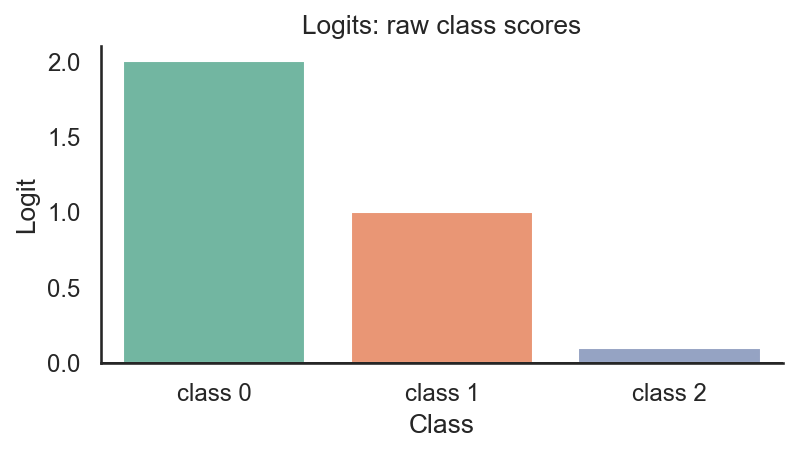

In [19]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
sns.barplot(x=class_names, y=logits, hue=class_names, palette="Set2", legend=False, ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Logits: raw class scores")
ax.set_xlabel("Class")
ax.set_ylabel("Logit")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 3. Softmax: 从 logits 到概率

对 $C$ 个类别，softmax 定义为：

$$
p_k = \frac{\exp(s_k)}{\sum_{j=1}^{C}\exp(s_j)}
$$

其中：

- $s_k$ 是第 $k$ 类的 logit。
- $p_k$ 是第 $k$ 类的预测概率。
- 所有概率满足 $p_k > 0$ 且 $\sum_k p_k = 1$。

softmax 保留了 logits 的相对大小：logit 越大，对应的概率通常越大。

**AI 使用指引。** 如果不理解 softmax 的形式，可以问 AI：`softmax 为什么用 exp？为什么输出和为 1？如果所有 logits 同时加上同一个常数，softmax 会不会变？` 重点是理解它把相对分数转换成类别概率。

In [20]:
def softmax_1d(scores):
    exp_scores = np.exp(scores)
    probs = exp_scores / exp_scores.sum()
    return probs


probs = softmax_1d(logits)

pd.DataFrame(
    {
        "class": class_names,
        "logit": logits,
        "exp(logit)": np.exp(logits),
        "softmax probability": probs,
    }
)

,class,logit,exp(logit),softmax probability
0,class 0,2.0,7.389056,0.659001
1,class 1,1.0,2.718282,0.242433
2,class 2,0.1,1.105171,0.098566


In [21]:
print(f"sum of probabilities = {probs.sum():.6f}")
print(f"predicted class = {np.argmax(probs)}")

sum of probabilities = 1.000000
predicted class = 0


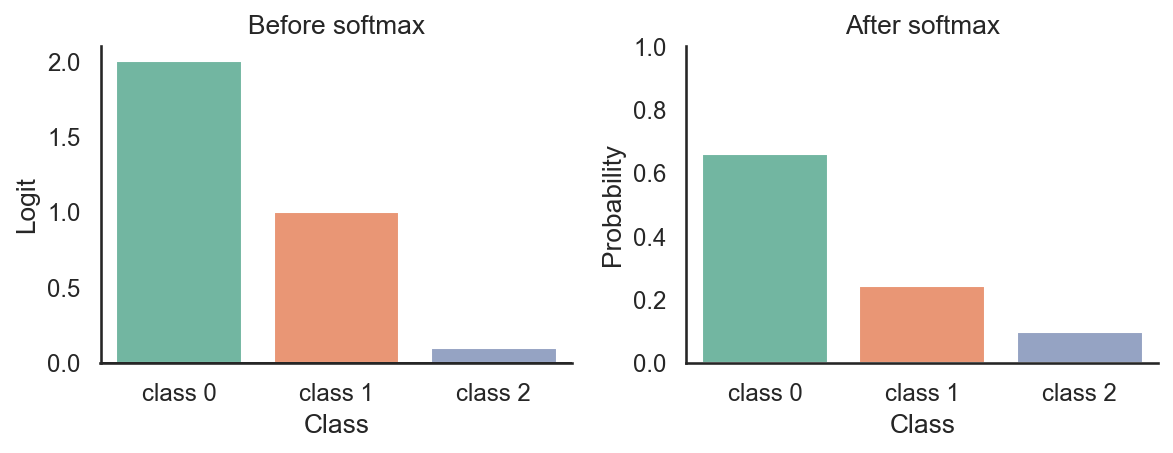

In [22]:
plot_df = pd.DataFrame(
    {
        "class": class_names + class_names,
        "value": np.concatenate([logits, probs]),
        "quantity": ["logit"] * 3 + ["softmax probability"] * 3,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
sns.barplot(
    data=plot_df[plot_df["quantity"] == "logit"],
    x="class",
    y="value",
    hue="class",
    palette="Set2",
    legend=False,
    ax=axes[0],
)
sns.barplot(
    data=plot_df[plot_df["quantity"] == "softmax probability"],
    x="class",
    y="value",
    hue="class",
    palette="Set2",
    legend=False,
    ax=axes[1],
)

axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Before softmax")
axes[0].set_ylabel("Logit")
axes[0].set_xlabel("Class")

axes[1].set_title("After softmax")
axes[1].set_ylabel("Probability")
axes[1].set_xlabel("Class")
axes[1].set_ylim(0, 1)

for axis in axes:
    sns.despine(ax=axis)

plt.tight_layout()
plt.show()

## 4. 数值稳定的 softmax

实际代码中通常不会直接计算 `np.exp(scores)`，因为 logits 很大时指数函数可能溢出。

softmax 有一个重要性质：给所有 logits 同时减去同一个常数，softmax 结果不变。

$$
\text{softmax}(s) = \text{softmax}(s - \max(s))
$$

所以常见实现会先减去最大 logit。

**AI 使用指引。** 如果不理解数值稳定，可以问 AI：`为什么计算 softmax 时常常要减去最大 logit？请说明这一步为什么不改变结果，以及它避免了什么数值问题。` 重点是区分数学等价和计算机浮点实现。

In [23]:
def stable_softmax_1d(scores):
    shifted_scores = scores - scores.max()
    exp_scores = np.exp(shifted_scores)
    probs = exp_scores / exp_scores.sum()
    return probs


large_logits = np.array([1002.0, 1001.0, 1000.1])

stable_probs = stable_softmax_1d(large_logits)
reference_probs = stable_softmax_1d(logits)

pd.DataFrame(
    {
        "class": class_names,
        "original logits": logits,
        "large logits": large_logits,
        "softmax(original)": reference_probs,
        "softmax(large)": stable_probs,
    }
)

,class,original logits,large logits,softmax(original),softmax(large)
0,class 0,2.0,1002.0,0.659001,0.659001
1,class 1,1.0,1001.0,0.242433,0.242433
2,class 2,0.1,1000.1,0.098566,0.098566


## 5. Cross entropy: 只关心真实类别的概率

如果真实标签是 $y$，cross entropy loss 是：

$$
L = -\log(p_y)
$$

其中 $p_y$ 是模型分配给真实类别的概率。

- 如果模型给真实类别很高概率，loss 很小。
- 如果模型给真实类别很低概率，loss 很大。

注意：这里的 $\log$ 是自然对数。

**AI 使用指引。** 如果 cross entropy 的直觉不清楚，可以问 AI：`为什么 -log(p_true) 适合做分类 loss？当真实类别概率从 0.9 变成 0.1 时，loss 如何变化？` 重点是理解 loss 如何惩罚“对真实类别不自信”。

In [24]:
true_label = 0
true_class_prob = probs[true_label]
loss = -np.log(true_class_prob)

print(f"true label = {true_label}")
print(f"p_y = {true_class_prob:.4f}")
print(f"cross entropy loss = -log(p_y) = {loss:.4f}")

true label = 0
p_y = 0.6590
cross entropy loss = -log(p_y) = 0.4170


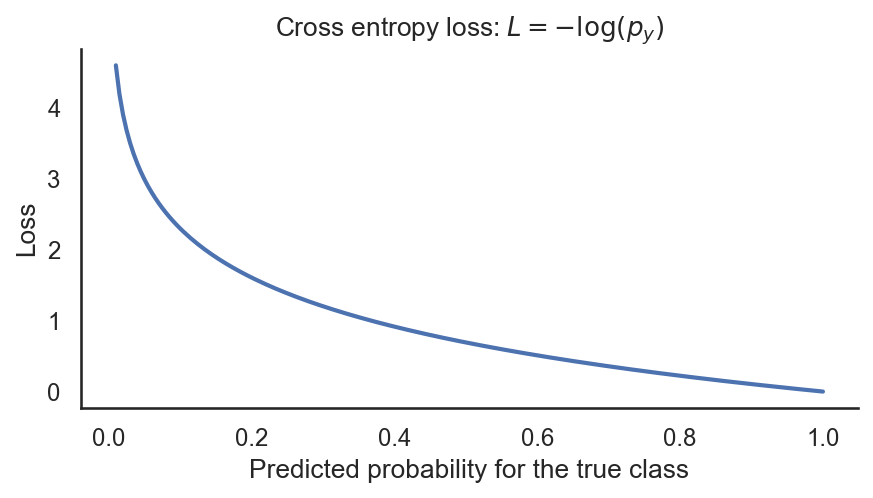

In [25]:
p_values = np.linspace(0.01, 1.0, 200)
loss_values = -np.log(p_values)
loss_curve = pd.DataFrame({"probability of true class": p_values, "cross entropy loss": loss_values})

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.lineplot(data=loss_curve, x="probability of true class", y="cross entropy loss", linewidth=2, ax=ax)
ax.set_title("Cross entropy loss: $L = -\\log(p_y)$")
ax.set_xlabel("Predicted probability for the true class")
ax.set_ylabel("Loss")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 6. Batch 版本：多个样本一起算

在训练中，我们通常一次处理一个 mini-batch。设 batch size 为 $B$，类别数为 $C$：

- logits: `shape = (B, C)`
- labels: `shape = (B,)`
- probs: `shape = (B, C)`

对第 $i$ 个样本，真实标签是 $y_i$，loss 是：

$$
L_i = -\log(p_{i, y_i})
$$

一个 batch 的 cross entropy 通常取平均：

$$
L = \frac{1}{B}\sum_{i=1}^{B} L_i
$$

In [26]:
batch_logits = np.array(
    [
        [2.0, 1.0, 0.1],   # sample 0
        [0.2, 1.8, 0.5],   # sample 1
        [0.1, 0.4, 2.2],   # sample 2
        [1.2, 1.0, 0.9],   # sample 3
    ]
)
labels = np.array([0, 1, 2, 2])

print(f"batch_logits.shape = {batch_logits.shape}")
print(f"labels.shape = {labels.shape}")

batch_logits.shape = (4, 3)
labels.shape = (4,)


In [27]:
def stable_softmax_2d(scores):
    shifted_scores = scores - scores.max(axis=1, keepdims=True)
    exp_scores = np.exp(shifted_scores)
    probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)
    return probs


batch_probs = stable_softmax_2d(batch_logits)
sample_indices = np.arange(len(labels))
true_class_probs = batch_probs[sample_indices, labels]
sample_losses = -np.log(true_class_probs)
mean_loss = sample_losses.mean()

pd.DataFrame(
    {
        "sample": sample_indices,
        "true label": labels,
        "p_true_class": true_class_probs,
        "sample loss": sample_losses,
    }
)

,sample,true label,p_true_class,sample loss
0,0,0,0.659001,0.417030
1,1,1,0.678229,0.388270
2,2,2,0.776545,0.252901
3,3,2,0.289433,1.239831


In [28]:
print(f"mean cross entropy loss = {mean_loss:.4f}")

mean cross entropy loss = 0.5745


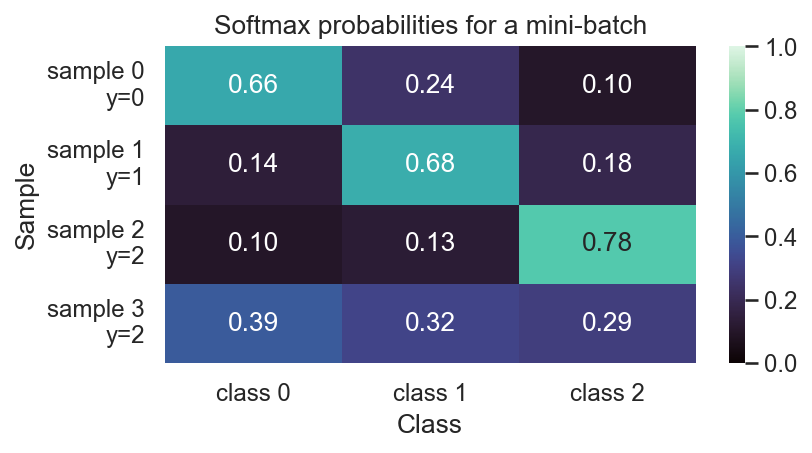

In [29]:
prob_heatmap = pd.DataFrame(batch_probs, columns=class_names)
prob_heatmap.index = [f"sample {i}\ny={label}" for i, label in enumerate(labels)]

fig, ax = plt.subplots(figsize=(5.8, 3.2))
sns.heatmap(prob_heatmap, annot=True, fmt=".2f", cmap="mako", vmin=0, vmax=1, ax=ax)
ax.set_title("Softmax probabilities for a mini-batch")
ax.set_xlabel("Class")
ax.set_ylabel("Sample")
plt.tight_layout()
plt.show()

## 7. PyTorch: `CrossEntropyLoss` expects logits

PyTorch 的 `nn.CrossEntropyLoss()` 会在内部完成：

1. 对 logits 做 `log_softmax`。
2. 取真实类别对应的负对数概率。
3. 对 batch 求平均。

因此，传入 `CrossEntropyLoss` 的应该是 raw logits，而不是已经 softmax 过的 probabilities。

**AI 使用指引。** 如果容易把 softmax 和 PyTorch loss 写混，可以问 AI：`nn.CrossEntropyLoss 内部做了哪些事情？为什么输入应该是 raw logits，而不是手动 softmax 后的 probabilities？` 重点是避免在训练代码里重复 softmax。

In [30]:
torch_logits = torch.tensor(batch_logits, dtype=torch.float32)
torch_labels = torch.tensor(labels, dtype=torch.long)

criterion = nn.CrossEntropyLoss()
torch_loss = criterion(torch_logits, torch_labels)

print(f"manual NumPy loss = {mean_loss:.6f}")
print(f"PyTorch CrossEntropyLoss = {torch_loss.item():.6f}")

manual NumPy loss = 0.574508
PyTorch CrossEntropyLoss = 0.574508


下面这段代码展示为什么不要先 softmax 再传给 `CrossEntropyLoss`。第二个 loss 的输入已经是概率，不再是 logits，因此含义错了。

In [31]:
torch_probs = torch.softmax(torch_logits, dim=1)
wrong_loss = criterion(torch_probs, torch_labels)

print(f"correct: CrossEntropyLoss(logits, labels) = {torch_loss.item():.6f}")
print(f"wrong:   CrossEntropyLoss(softmax(logits), labels) = {wrong_loss.item():.6f}")

correct: CrossEntropyLoss(logits, labels) = 0.574508
wrong:   CrossEntropyLoss(softmax(logits), labels) = 0.859521


## 8. 梯度直觉：提高真实类别的 logit

为了训练模型，我们需要知道 loss 对 logits 的梯度。对 softmax + cross entropy，有一个很简洁的结果：

$$
\frac{\partial L}{\partial s_k} = p_k - \mathbb{1}(k = y)
$$

如果真实类别是 $y$：

- 对真实类别，梯度通常是负数，梯度下降会提高这个 logit。
- 对其他类别，梯度通常是正数，梯度下降会降低这些 logits。

对于 batch mean loss，梯度还会再除以 batch size $B$。

**AI 使用指引。** 如果梯度方向不清楚，可以问 AI：`对一个分类样本，cross entropy 的梯度为什么会鼓励提高真实类别 logit、降低其他类别 logit？请用直觉解释，不要展开完整推导。` 重点是把 loss 下降和 logits 调整方向联系起来。

In [32]:
torch_logits_for_grad = torch.tensor(batch_logits, dtype=torch.float32, requires_grad=True)
loss_for_grad = criterion(torch_logits_for_grad, torch_labels)
loss_for_grad.backward()

autograd_grad = torch_logits_for_grad.grad.detach().numpy()

one_hot_labels = np.zeros_like(batch_probs)
one_hot_labels[sample_indices, labels] = 1.0
manual_grad = (batch_probs - one_hot_labels) / len(labels)

print("PyTorch autograd gradient:")
print(np.round(autograd_grad, 4))
print("\nManual gradient: (probs - one_hot) / B")
print(np.round(manual_grad, 4))

PyTorch autograd gradient:
[[-0.0852  0.0606  0.0246]
 [ 0.0342 -0.0804  0.0462]
 [ 0.0238  0.0321 -0.0559]
 [ 0.0977  0.08   -0.1776]]

Manual gradient: (probs - one_hot) / B
[[-0.0852  0.0606  0.0246]
 [ 0.0342 -0.0804  0.0462]
 [ 0.0238  0.0321 -0.0559]
 [ 0.0977  0.08   -0.1776]]


## 9. 和 MNIST 10 类分类的连接

回到 MNIST：如果 mini-batch 有 $B$ 张图片，flatten 后：

$$
X \in \mathbb{R}^{B \times 784}
$$

线性分类器输出：

$$
S = XW + b, \quad S \in \mathbb{R}^{B \times 10}
$$

训练时的常见写法是：

```python
logits = model(X)                  # shape: (B, 10)
loss = criterion(logits, labels)   # labels shape: (B,)
```

这里的 `criterion` 通常就是 `nn.CrossEntropyLoss()`。不要写成 `criterion(torch.softmax(logits, dim=1), labels)`。